# DenseNet121 Transfer Learning — Head Only, Swimcat-extend

DenseNet121 head-only fine-tuning on the Swimcat-extend dataset.
Backbone is fully frozen; only the final classifier layer is trained.
Swimcat-extend is clean so no CSV filtering is needed — images are loaded
directly from the class subdirectories.

Differences from `12_transfer_learning_densenet121.ipynb`:
- Dataset: Swimcat-extend (2,100 images, 6 classes) instead of NASA GLOBE filtered
- No CSV filtering — simple folder scan replaces `index_labeled_images_filtered`
- 6-class head instead of 10-class
- Balanced dataset — plain shuffle replaces `WeightedRandomSampler`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

IMAGES_ROOT = Path("../resources/cloud-images/Swimcat-extend")
IMAGE_EXTS  = {".jpg", ".jpeg", ".png"}

def index_labeled_images(images_root):
    labeled_images = {}
    for class_dir in sorted(images_root.iterdir()):
        if not class_dir.is_dir():
            continue
        for img_path in sorted(class_dir.iterdir()):
            if img_path.suffix.lower() in IMAGE_EXTS:
                labeled_images[img_path.name] = {
                    "label": class_dir.name,
                    "path":  str(img_path),
                }
    return labeled_images

labeled_images = index_labeled_images(IMAGES_ROOT)

counts = Counter(v["label"] for v in labeled_images.values())
for folder in sorted(counts):
    print(f"  {folder:25s}  {counts[folder]:,}")
print(f"  {'TOTAL':25s}  {sum(counts.values()):,}")

  A-Clear Sky                350
  B-Patterned Clouds         350
  C-Thin White Clouds        350
  D-Thick White Clouds       350
  E-Thick Dark Clouds        350
  F-Veil Clouds              350
  TOTAL                      2,100


In [2]:
def extract_labels(labeled_images):
    paths, labels = [], []
    for image_name in labeled_images:
        paths.append(labeled_images[image_name]["path"])
        labels.append(labeled_images[image_name]["label"])
    return paths, np.array(labels)

paths, labels = extract_labels(labeled_images)

In [3]:
import torch

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"device: {device}")

device: mps


In [4]:
import torchvision.transforms.v2 as T
from torchvision.transforms.v2 import InterpolationMode

IMG_SIZE = (224, 224)
MAX_FRAC = 0.14

border_translation = T.RandomAffine(
    degrees=0,
    translate=(MAX_FRAC, MAX_FRAC),
    interpolation=InterpolationMode.BILINEAR,
    fill=0
)

# T.Lambda is fine locally with num_workers=0
wrap_translation = T.Lambda(lambda x: torch.roll(
    x,
    shifts=(
        int(torch.randint(-int(MAX_FRAC * x.shape[-2]), int(MAX_FRAC * x.shape[-2]) + 1, (1,)).item()),
        int(torch.randint(-int(MAX_FRAC * x.shape[-1]), int(MAX_FRAC * x.shape[-1]) + 1, (1,)).item()),
    ),
    dims=(-2, -1),
))

stacked = T.Compose([
    T.RandomChoice([wrap_translation, border_translation]),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.15),
    T.RandomAffine(
        degrees=20, scale=(0.90, 1.10),
        interpolation=InterpolationMode.BILINEAR, fill=0
    ),
    T.RandomResizedCrop(
        size=IMG_SIZE, scale=(0.80, 1.00), ratio=(0.90, 1.10),
        interpolation=InterpolationMode.BILINEAR
    ),
])

one_of = T.RandomChoice([
    wrap_translation,
    border_translation,
    T.RandomChoice([T.RandomHorizontalFlip(p=1.0), T.RandomVerticalFlip(p=1.0)]),
    T.RandomRotation(degrees=20, interpolation=InterpolationMode.BILINEAR, fill=0),
])

normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

train_transforms = T.Compose([
    T.Resize(IMG_SIZE, interpolation=InterpolationMode.BILINEAR),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.RandomChoice([stacked, one_of]),
    normalize,
])

eval_transforms = T.Compose([
    T.Resize(IMG_SIZE, interpolation=InterpolationMode.BILINEAR),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    normalize,
])

In [5]:
import torchvision
import torch.nn as nn

weights = torchvision.models.DenseNet121_Weights.IMAGENET1K_V1
model = torchvision.models.densenet121(weights=weights).to(device)
print("DenseNet121 loaded")

DenseNet121 loaded


In [6]:
from sklearn.preprocessing import LabelEncoder

def encode_labels(labels):
    ordinal_encoder = LabelEncoder()
    encoded_labels = ordinal_encoder.fit_transform(labels)
    return encoded_labels, ordinal_encoder.classes_

encoded_labels, class_names = encode_labels(labels)
print(f"Classes ({len(class_names)}): {class_names}")

Classes (6): ['A-Clear Sky' 'B-Patterned Clouds' 'C-Thin White Clouds'
 'D-Thick White Clouds' 'E-Thick Dark Clouds' 'F-Veil Clouds']


In [7]:
from torch.utils.data import Dataset
from sklearn.model_selection import StratifiedShuffleSplit
from PIL import Image

class MyImages(Dataset):
    def __init__(self, paths, encoded_labels, split="train", test_size=0.2, val_size=0.1,
                 random_state=42, transform=None, split_indices=None):
        if split not in {None, "train", "val", "test"}:
            raise ValueError(f"split must be one of {{'None','train','val','test'}}, got {split!r}")

        self.transform = transform
        paths = np.array(list(paths))
        encoded_labels = np.array(list(encoded_labels))

        if split_indices is None:
            sss1 = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
            trainval_idx, test_idx = next(sss1.split(paths, encoded_labels))

            val_within_trainval = val_size / (1.0 - test_size)
            sss2 = StratifiedShuffleSplit(n_splits=1, test_size=val_within_trainval, random_state=random_state)
            train_rel_idx, val_rel_idx = next(sss2.split(paths[trainval_idx], encoded_labels[trainval_idx]))

            split_indices = {
                "train": trainval_idx[train_rel_idx],
                "val":   trainval_idx[val_rel_idx],
                "test":  test_idx,
            }

        idx = split_indices[split]
        self.paths = paths[idx].tolist()
        self.encoded_labels = encoded_labels[idx].tolist()

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.encoded_labels[idx]


paths_arr  = np.array(list(paths))
labels_arr = np.array(list(encoded_labels))

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
trainval_idx, test_idx = next(sss1.split(paths_arr, labels_arr))

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.1/0.8, random_state=42)
train_rel_idx, val_rel_idx = next(sss2.split(paths_arr[trainval_idx], labels_arr[trainval_idx]))

split_indices = {
    "train": trainval_idx[train_rel_idx],
    "val":   trainval_idx[val_rel_idx],
    "test":  test_idx,
}

train_set = MyImages(paths=paths, encoded_labels=encoded_labels,
                     split="train", transform=train_transforms,
                     split_indices=split_indices)
valid_set = MyImages(paths=paths, encoded_labels=encoded_labels,
                     split="val",   transform=eval_transforms,
                     split_indices=split_indices)
test_set  = MyImages(paths=paths, encoded_labels=encoded_labels,
                     split="test",  transform=eval_transforms,
                     split_indices=split_indices)

print(f"train: {len(train_set):,}  val: {len(valid_set):,}  test: {len(test_set):,}")

train: 1,470  val: 210  test: 420


In [8]:
from torch.utils.data import DataLoader

# Swimcat-extend is perfectly balanced (350/class) so plain shuffle is sufficient
train_loader = DataLoader(train_set, batch_size=64, shuffle=True,  num_workers=0)
valid_loader = DataLoader(valid_set, batch_size=64, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=64, shuffle=False, num_workers=0)

In [9]:
n_classes = len(class_names)  # 6

# Freeze entire backbone
for param in model.parameters():
    param.requires_grad = False

# Replace classifier with a new head — only this will be trained
model.classifier = nn.Linear(model.classifier.in_features, n_classes).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

Trainable params: 6,150 / 6,960,006


In [10]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs, patience=20, checkpoint_path="best_model.pt"):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    best_val = 0.0
    epochs_without_improvement = 0

    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        # Keep model in eval mode to fix BatchNorm running stats in the frozen backbone.
        # The classifier head is a plain Linear layer so train vs eval makes no difference for it.
        model.eval()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)

        train_loss = total_loss / len(train_loader)
        train_acc  = metric.compute().item()
        val_acc    = evaluate_tm(model, valid_loader, metric).item()

        history["train_losses"].append(train_loss)
        history["train_metrics"].append(train_acc)
        history["valid_metrics"].append(val_acc)

        print(f"Epoch {epoch + 1}/{n_epochs} | "
              f"loss: {train_loss:.4f} | "
              f"train: {train_acc:.4f} | "
              f"val: {val_acc:.4f}"
              + (" *" if val_acc > best_val else ""))

        if val_acc > best_val:
            best_val = val_acc
            epochs_without_improvement = 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch + 1} (best val: {best_val:.4f})")
                break

    model.load_state_dict(torch.load(checkpoint_path, weights_only=True))
    return history

In [11]:
n_epochs  = 100
optimizer = torch.optim.AdamW(model.classifier.parameters())
xentropy  = nn.CrossEntropyLoss()
accuracy  = torchmetrics.Accuracy(task="multiclass", num_classes=n_classes).to(device)

history = train(
    model, optimizer, xentropy, accuracy,
    train_loader, valid_loader,
    n_epochs, patience=20,
    checkpoint_path="best_model_13_densenet121_swimcat.pt",
)

test_acc = evaluate_tm(model, test_loader, accuracy)
print(f"\nTest accuracy: {test_acc:.4f}")

Epoch 1/100 | loss: 1.4661 | train: 0.5327 | val: 0.6667 *
Epoch 2/100 | loss: 0.9498 | train: 0.8163 | val: 0.8905 *
Epoch 3/100 | loss: 0.6801 | train: 0.9061 | val: 0.9333 *
Epoch 4/100 | loss: 0.5514 | train: 0.9211 | val: 0.9381 *
Epoch 5/100 | loss: 0.4729 | train: 0.9197 | val: 0.9333
Epoch 6/100 | loss: 0.4120 | train: 0.9259 | val: 0.9429 *
Epoch 7/100 | loss: 0.3700 | train: 0.9367 | val: 0.9524 *
Epoch 8/100 | loss: 0.3285 | train: 0.9449 | val: 0.9476
Epoch 9/100 | loss: 0.3160 | train: 0.9367 | val: 0.9619 *
Epoch 10/100 | loss: 0.2971 | train: 0.9435 | val: 0.9619
Epoch 11/100 | loss: 0.2666 | train: 0.9490 | val: 0.9571
Epoch 12/100 | loss: 0.2465 | train: 0.9558 | val: 0.9619
Epoch 13/100 | loss: 0.2400 | train: 0.9503 | val: 0.9667 *
Epoch 14/100 | loss: 0.2374 | train: 0.9429 | val: 0.9619
Epoch 15/100 | loss: 0.2250 | train: 0.9517 | val: 0.9619
Epoch 16/100 | loss: 0.2042 | train: 0.9558 | val: 0.9619
Epoch 17/100 | loss: 0.2067 | train: 0.9497 | val: 0.9619
Epoch 1

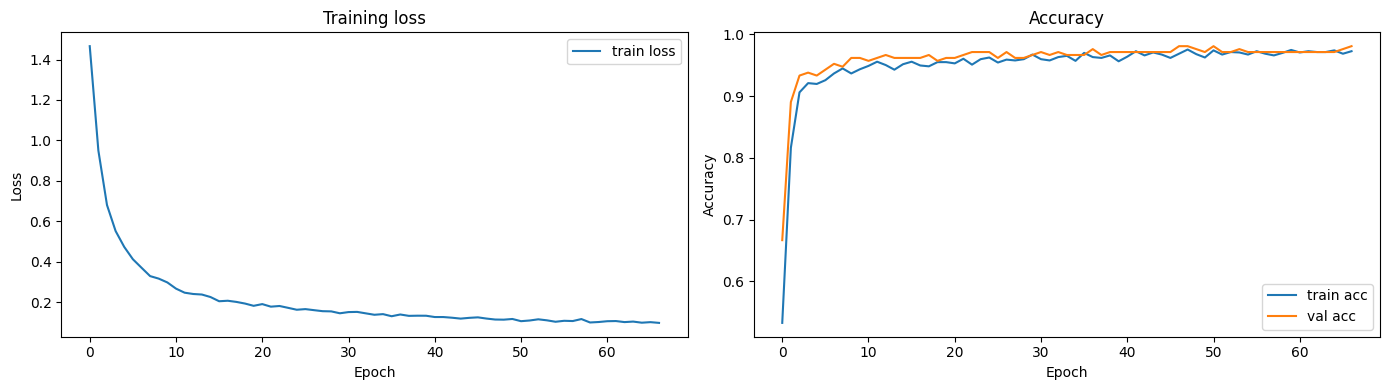

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history["train_losses"], label="train loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training loss")
axes[0].legend()

axes[1].plot(history["train_metrics"], label="train acc")
axes[1].plot(history["valid_metrics"], label="val acc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

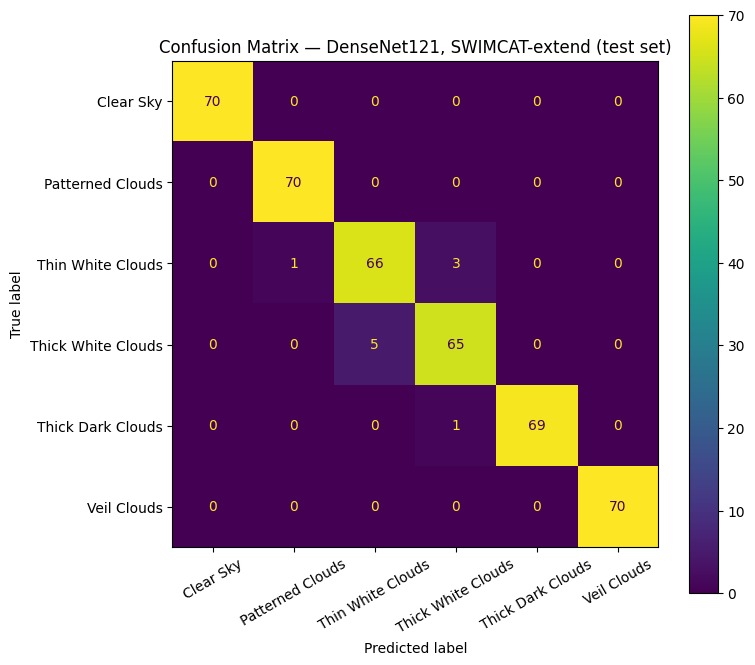

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

short_names = [c.split("-", 1)[1] for c in class_names]  # strip leading "A-", "B-", etc.

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=short_names)
disp.plot(ax=ax, colorbar=True, xticks_rotation=30)
ax.set_title("Confusion Matrix — DenseNet121, SWIMCAT-extend (test set)")
plt.tight_layout()
plt.show()